In [33]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install matplotlib.pyplot


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot

[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
! pip install pandas_datareader


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
!pip install getFamaFrenchFactors



[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# GENERAL USE LIBRARY IMPORTS

import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
import pandas_datareader.data as reader
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
yf.pdr_override()

# OPTIMIZATION LIBRARY IMPORTS
import pulp
from pulp import *
from sklearn.preprocessing import LabelEncoder

In [38]:
#Getting SP_500 Tickers as a list
list_of_dfs = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
wikitable_sp_500 = list_of_dfs[0]
sp500_symbols = wikitable_sp_500['Symbol']

In [39]:
#Converting SP_500 tickers into list 
tickers = sp500_symbols.to_list()
#Remove some tickers as they create an error for the yfinance api
tickers[65] = 'BRK-B'
tickers[81] = 'BF-B'
tickers.remove('BF-B')
tickers.remove('BRK-B')

In [40]:
#Start Date for In Sample Historical Data
start = '2020-05-01'
#End Date for In Sample Historical Data
end   = '2023-06-01'
#Monthly Returns for Stocks in the List
monthly_data = yf.download(tickers,start=start,end=end,interval='1mo')
#Reformat Date Index 
monthly_data.index = pd.to_datetime(monthly_data.index)
monthly_data = monthly_data.tz_localize(None)
#Turn Adj Close prices into pct returns
monthly_data = monthly_data['Adj Close'].pct_change()
#Drop First row NaN values
monthly_data = monthly_data.drop(monthly_data.index[0])
#Drop if stock doesnt have data starting from the first index date
monthly_data = monthly_data.dropna(axis=1)
#Assign equal weight as base weights
base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])
#Getting SP_500 data
spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())
#Dropping First Row(NaN) and formatting index to match monthly_data 
spy = spy.drop(spy.index[0]).tz_localize(None)
#Adding SP_500 data to monthly_data
monthly_data['SP_500'] = spy['Adj Close']

[*********************100%***********************]  501 of 501 completed


5 Failed downloads:
['VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1588305600, endDate = 1685592000")
['EG', 'BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-05-01 -> 2023-06-01)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
['KVUE']: IndexError('index 0 is out of bounds for axis 0 with size 0')



[*********************100%***********************]  1 of 1 completed


In [41]:
#Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
tickers = list(monthly_data.columns[:-1])
tick_index = tickers + ['SP_500']

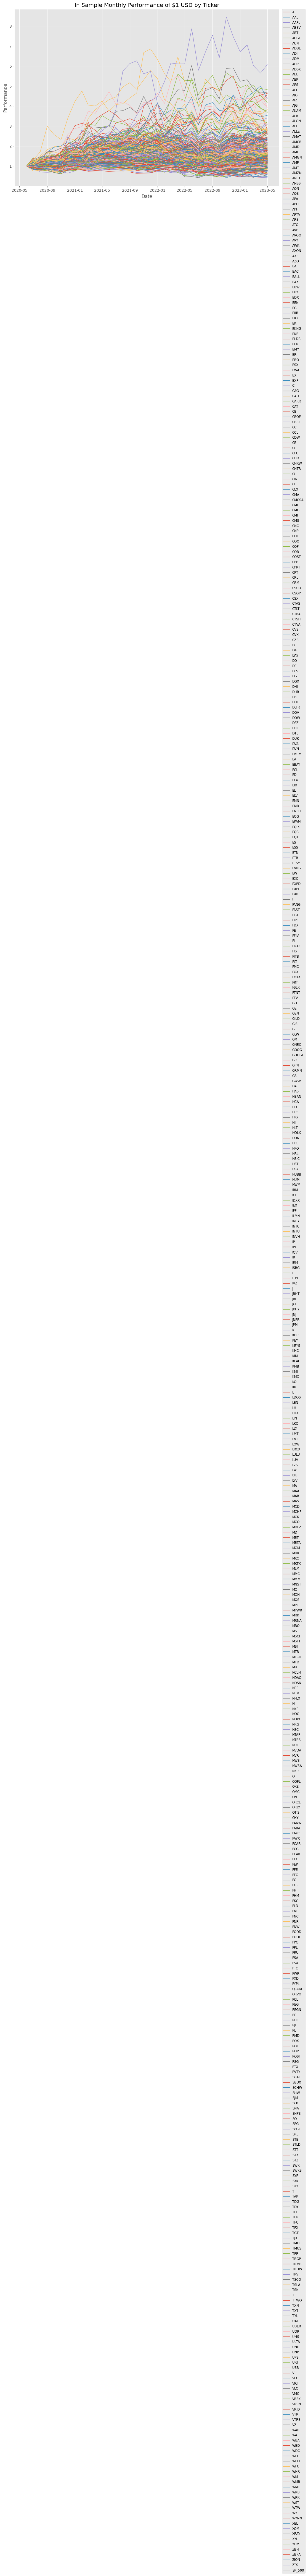

In [42]:
# IN SAMPLE HISTORICAL MONTHLY PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

performance = pd.DataFrame(np.ones((len(monthly_data),len(monthly_data.columns))), index = monthly_data.index, columns = monthly_data.columns)
for j in range(1,len(monthly_data.index)):
    performance.iloc[j] = performance.iloc[j-1]*(monthly_data.iloc[j-1][monthly_data.columns]+init)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(monthly_data.columns)):
        axes.plot(performance.index, performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('In Sample Monthly Performance of $1 USD by Ticker')
axes.legend(tick_index, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()

In [43]:
# Fama French Monthly Returns Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
ff3_monthly = ff3_monthly.loc[monthly_data.index]

In [44]:
# Correlation of Factor Returns
ff3_monthly.corr()

,Mkt-RF,SMB,HML,RF
Mkt-RF,1.000000,0.154466,-0.188295,-0.059297
SMB,0.154466,1.000000,-0.129832,-0.091568
HML,-0.188295,-0.129832,1.000000,-0.318977
RF,-0.059297,-0.091568,-0.318977,1.000000


In [45]:
# Stats for Factor Returns
ff3_monthly.describe()

,Mkt-RF,SMB,HML,RF
count,36.000000,36.000000,36.000000,36.000000
mean,0.009814,0.000886,0.006961,0.000908
std,0.052935,0.031127,0.049476,0.001366
min,-0.094600,-0.059400,-0.088500,0.000000
25%,-0.023625,-0.019550,-0.019075,0.000000
50%,0.018650,-0.002350,-0.000950,0.000100
75%,0.046075,0.020625,0.035075,0.001900
max,0.124700,0.073600,0.127500,0.003600


In [46]:
# Create an empty DataFrame to store the Stock Betas
stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in monthly_data.columns:
    # Set the dependent variable (Return of stock i)
    y = monthly_data[col]
    
    # Set the independent variables (Fama French 3 Factors)
    X = ff3_monthly[['Mkt-RF','SMB','HML']]
    
    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Store the results in the DataFrame
    stock_betas[col] = [model.intercept_] + list(model.coef_)
stock_betas = stock_betas.T
stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

C:\Users\Johanan Anton\AppData\Local\Temp\ipykernel_14556\3614759814.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stock_betas[col] = [model.intercept_] + list(model.coef_)
C:\Users\Johanan Anton\AppData\Local\Temp\ipykernel_14556\3614759814.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stock_betas[col] = [model.intercept_] + list(model.coef_)
C:\Users\Johanan Anton\AppData\Local\Temp\ipykernel_14556\3614759814.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

In [47]:
# Check the Betas for an individual stock - Put the ticker of the desired stock in the ' '.
stock_betas.loc['AAPL']

Intercept    0.018996
Mkt-RF       1.269937
SMB         -0.349982
HML         -0.584069
Name: AAPL, dtype: float64

In [48]:
# Stats for Stock Betas
stock_betas.describe()

,Intercept,Mkt-RF,SMB,HML
count,494.000000,494.000000,494.000000,494.000000
mean,0.002114,1.006626,0.019775,0.277337
std,0.011565,0.377068,0.615031,0.523948
min,-0.039306,0.013693,-1.204090,-1.430609
25%,-0.003776,0.757053,-0.403140,-0.034323
50%,0.001946,0.983834,-0.063737,0.226063
75%,0.007944,1.236578,0.364963,0.598942
max,0.048138,2.441397,2.549699,2.171452


In [49]:
#Stock Prices on the Day of Optimization(Rebalancing)
stock_price = pd.DataFrame(yf.download(tickers,start=start,end=end,interval='1d')['Adj Close'])
stock_price = stock_price[-1:]
stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)

s_price = {}
s_keys = list(tickers)
s_values =  list(stock_price.iloc[0])
for key,value in zip(s_keys,s_values):
    s_price[key] = value

[*********************100%***********************]  493 of 493 completed


In [50]:
#Transaction Costs
random.seed(1)
t_cost = {}
keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
values = list(random.uniform(.01,.02) for i in range(len(tickers)))
for key,value in zip(keys,values):
    t_cost[key] = value

In [51]:
#SP_500 Factor Betas
stock_betas.iloc[-1,1:]

Mkt-RF    0.985868
SMB      -0.187391
HML       0.008352
Name: SP_500, dtype: float64

In [52]:
     # TARGET FACTOR BETAS 
mkt_opt = 1.21                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
smb_opt = .30                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
hml_opt = 0.8                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
B = 1000000                             # BUDGET
q = 80                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
base_weights = base_w.T*0          # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH                                      


In [53]:
# OPTIMIZATION MODEL

index = LpProblem('Index', LpMinimize)

# Decision Variables

wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio


#Objective Function - Minimize the error term 
index +=  lpSum(err[t] for t in monthly_data.index)

# Constraint: Weights sum to 1 
index += lpSum(wei[i] for i in tickers) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    index += aux[i] >= base_weights[i]  - wei[i]
    index += aux[i] >= wei[i] - base_weights[i]
index += lpSum(aux[i] for i in tickers) <= 1
# Constraint: Error term
for t in monthly_data.index:
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])

# Shares
for i in tickers:
    index += shares[i] == (aux[i]*B/s_price[i])

# Transaction Costs
for i in tickers:
    index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
index += lpSum(tr_cost[i] for i in tickers) <= 2000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    index += wei[i] <= binary[i]
    
index += lpSum(binary[i] for i in tickers) <= q

index.solve()

1

In [54]:
!pip install openpyxl


[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
#Change in number of shares
sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
sharess
sharess.to_excel('shares.xlsx')

In [56]:
#Transaction Costs
tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
tr_cost.sum()

Optimal    369.537911
dtype: float64

In [57]:
#Optimal weights
weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
weii.sum()

Optimal    1.0
dtype: float64

In [58]:
#Change of weights
auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
auxx.sum()

Optimal    1.0
dtype: float64

In [59]:
#Error terms
errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
errr.sum()

Optimal    0.0
dtype: float64

In [60]:
# Check if Binary Values Constraint works
binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
binary_v.sum()

Optimal    38.0
dtype: float64

In [61]:
# Weights in Optimal Portfolio
opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
opt_weights.style.format('{:,.2%}'.format)

,Optimal
Weight_ADM,3.32%
Weight_AMAT,1.03%
Weight_APA,5.39%
Weight_BAC,3.88%
Weight_BG,3.21%
Weight_BX,3.03%
Weight_C,2.57%
Weight_CAT,0.40%
Weight_COF,0.78%
Weight_DD,3.46%


In [62]:

weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in monthly_data.columns[:-1]:
    weights.loc[t][0] = base_w.loc[t]
    weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
    weights.loc[t][2] = weights_new.loc[t]
weights

,PORTFOLIO Weights,Difference,New Weights
A,0.002028,-0.002028,0.000000
AAL,0.002028,-0.002028,0.000000
AAPL,0.002028,-0.002028,0.000000
ABBV,0.002028,-0.002028,0.000000
ABT,0.002028,-0.002028,0.000000
...,...,...,...
YUM,0.002028,-0.002028,0.000000
ZBH,0.002028,-0.002028,0.000000
ZBRA,0.002028,-0.002028,0.000000
ZION,0.002028,0.018655,0.020683


In [63]:
# CHECK PORTFOLIO BETAS

port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
for j in port_returns.index:
    port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
    port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])

port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = port_returns['SP_500']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['SP_500'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
port_betas

,SP_500,Target,Optimization,Abs. Diff
Mkt-RF,0.985868,1.21,1.207228,0.0028
SMB,-0.187391,0.30,0.294688,0.0053
HML,0.008352,0.80,0.790202,0.0098


In [64]:
fama_stocks_future_df=opt_weights
i=0
fama_stocks_future_beta_df=pd.DataFrame()
for index, row in fama_stocks_future_df.iterrows():
    row_name = index
    fama_stocks_future = index.replace('Weight_', '')
    fama_stocks_future_beta=stock_betas.loc[fama_stocks_future]
    fama_stocks_future_beta_df[fama_stocks_future]=fama_stocks_future_beta
fama_stocks_future_beta_df.drop("Intercept", inplace=True)
fama_stocks_future_beta_df
for column in fama_stocks_future_beta_df.columns:
    max_abs_row = fama_stocks_future_beta_df[column].abs().idxmax()
    if max_abs_row == "HML":
        max_abs_row="Value stock"
    elif max_abs_row=="SMB":
        max_abs_row="Small Cap stock"
    else:
        max_abs_row="Market Risk stock"
    fama_stocks_future_beta_df.at['Stock Type', column] = max_abs_row

fama_stocks_future_beta_df.transpose() 

,Mkt-RF,SMB,HML,Stock Type
ADM,0.789127,-0.525807,0.829176,Value stock
AMAT,1.702109,0.875127,0.370098,Market Risk stock
APA,1.964179,0.384542,1.872521,Market Risk stock
BAC,1.387151,0.395463,1.064499,Market Risk stock
BG,0.857498,0.137624,1.01466,Value stock
BX,1.610453,-0.052744,0.366433,Market Risk stock
C,1.419488,0.688799,1.066152,Market Risk stock
CAT,1.316053,0.117462,0.885742,Market Risk stock
COF,1.128148,0.950935,0.730608,Market Risk stock
DD,1.091137,0.264091,0.504341,Market Risk stock
